In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nabinkhanal1","key":"c2977ddc93dfa40475d082955591bf9f"}'}

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d inspiring-lab/nepali-number-plate-characters-dataset

Dataset URL: https://www.kaggle.com/datasets/inspiring-lab/nepali-number-plate-characters-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
 70% 22.0M/31.6M [00:00<00:00, 103MB/s] 
100% 31.6M/31.6M [00:00<00:00, 80.6MB/s]


In [3]:
!unzip /content/nepali-number-plate-characters-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: character_ocr/४/४_375.jpg  
  inflating: character_ocr/४/४_376.jpg  
  inflating: character_ocr/४/४_377.jpg  
  inflating: character_ocr/४/४_378.jpg  
  inflating: character_ocr/४/४_379.jpg  
  inflating: character_ocr/४/४_38.jpg  
  inflating: character_ocr/४/४_380.jpg  
  inflating: character_ocr/४/४_381.jpg  
  inflating: character_ocr/४/४_382.jpg  
  inflating: character_ocr/४/४_383.jpg  
  inflating: character_ocr/४/४_384.jpg  
  inflating: character_ocr/४/४_385.jpg  
  inflating: character_ocr/४/४_386.jpg  
  inflating: character_ocr/४/४_387.jpg  
  inflating: character_ocr/४/४_388.jpg  
  inflating: character_ocr/४/४_389.jpg  
  inflating: character_ocr/४/४_39.jpg  
  inflating: character_ocr/४/४_390.jpg  
  inflating: character_ocr/४/४_391.jpg  
  inflating: character_ocr/४/४_392.jpg  
  inflating: character_ocr/४/४_393.jpg  
  inflating: character_ocr/४/४_394.jpg  
  inflating: character_ocr/४/४_395.jpg  
  inflat

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np
import os

In [5]:
image_size = (64, 64)  # Resize images to 64x64
batch_size = 32
num_classes = 34

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    '/content/character_ocr',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 26537 images belonging to 34 classes.


In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
validation_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
validation_generator = validation_datagen.flow_from_directory(
    '/content/character_ocr',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 26537 images belonging to 34 classes.


In [12]:
history = model.fit(train_generator, epochs=25, validation_data=validation_generator)

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


830/830 ━━━━━━━━━━━━━━━━━━━━ 69s 77ms/step - accuracy: 0.1903 - loss: 2.8773 - val_accuracy: 0.7200 - val_loss: 0.9177
Epoch 2/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.6026 - loss: 1.3217 - val_accuracy: 0.8660 - val_loss: 0.4945
Epoch 3/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 60s 71ms/step - accuracy: 0.7323 - loss: 0.8759 - val_accuracy: 0.8835 - val_loss: 0.3808
Epoch 4/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.7881 - loss: 0.7039 - val_accuracy: 0.9076 - val_loss: 0.2917
Epoch 5/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step - accuracy: 0.8179 - loss: 0.6023 - val_accuracy: 0.9036 - val_loss: 0.3166
Epoch 6/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 58s 70ms/step - accuracy: 0.8373 - loss: 0.5280 - val_accuracy: 0.9318 - val_loss: 0.2243
Epoch 7/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step - accuracy: 0.8520 - loss: 0.4799 - val_accuracy: 0.9366 - val_loss: 0.2089
Epoch 8/25
830/830 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.8656 - loss: 0.4303 - val_accurac

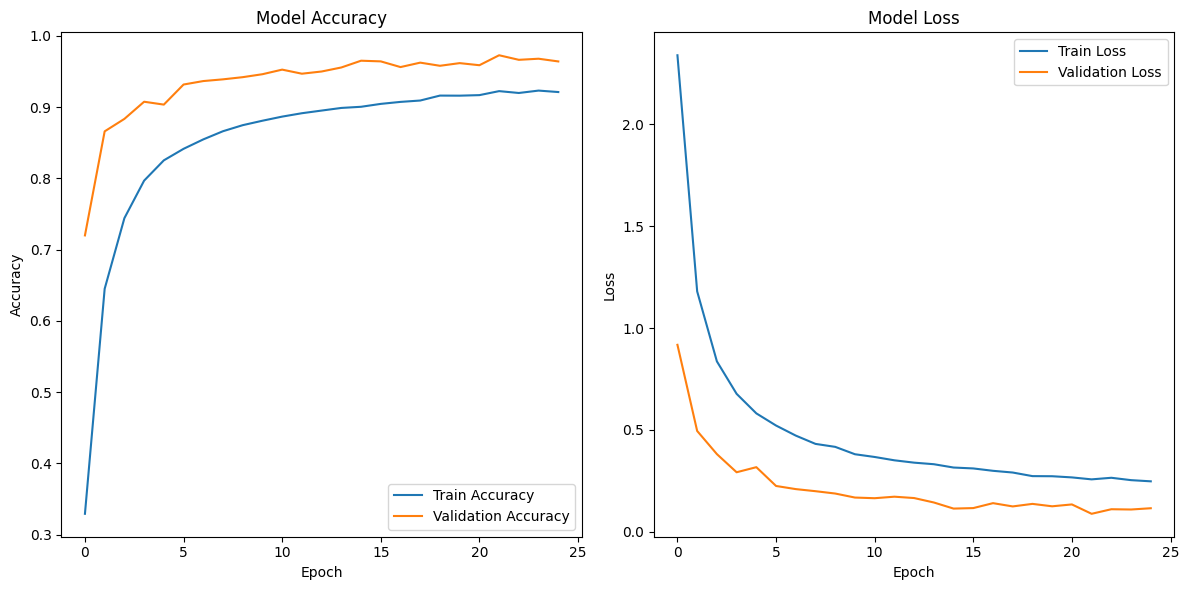

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [14]:
import torch
torch.save(model, "model.pth")

In [15]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
model.save('character_model.h5')

In [27]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
image_path = '/content/character_ocr/म/म_12.jpg'
image = load_img(image_path, target_size=(64, 64))  # Resize to the input shape of your model
image_array = img_to_array(image)  # Convert the image to a NumPy array
image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension
image_array = image_array / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted class: 16, Probability: 0.9308


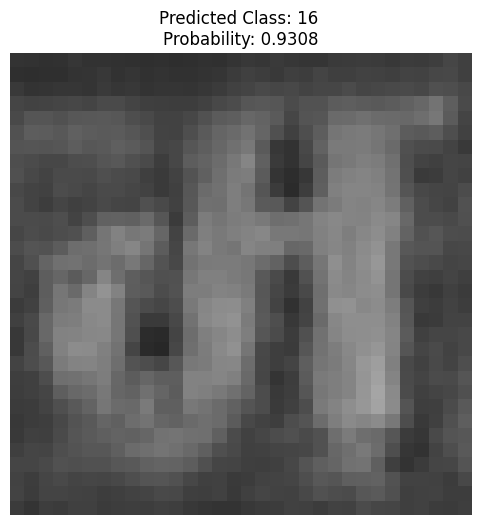

In [28]:
predictions = model.predict(image_array)

predicted_class = np.argmax(predictions, axis=1)[0]
predicted_probability = np.max(predictions)  # Get the highest probability

# Print predicted class and probability
print(f"Predicted class: {predicted_class}, Probability: {predicted_probability:.4f}")

# Plot the image with predicted class
plt.figure(figsize=(6, 6))
plt.imshow(image)  # Show the original image
plt.title(f"Predicted Class: {predicted_class} \nProbability: {predicted_probability:.4f}")
plt.axis('off')  # Hide axes
plt.show()